## Model training 
- LogisticRegression 
- SVC
- RandomForestClassifier 
- LinearRegression 
- RandomForestRegression 
- KMeans 

### LigisticRegression Example 


Feature shape :  (569, 30)
Target names :  ['malignant' 'benign']
Feature names :  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
X_train shape :  (455, 30)
y_train shape :  (455,)
<class 'dict'>

Cross validation results 
accuracy: 0.9780 +- 0.0098
precision: 0.9795 +- 0.0162
recall: 0.9860 +- 0.0131
f1: 0.9825 +- 0.0078
roc_auc: 0.9959 +- 0.0050

Test performance : 
Accuracy : 0.9824561403508771
Precisi0on :  0.9861111111111112
Recall :  0.9861111111111112
F1 score :  0.9861111111111112
ROC-AUC : 0.9953703703703703

Classification report: 
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



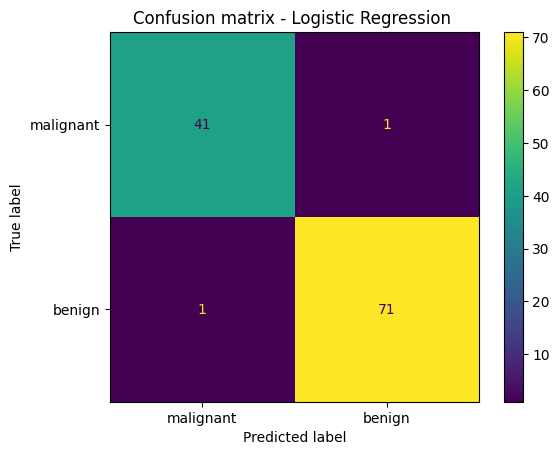

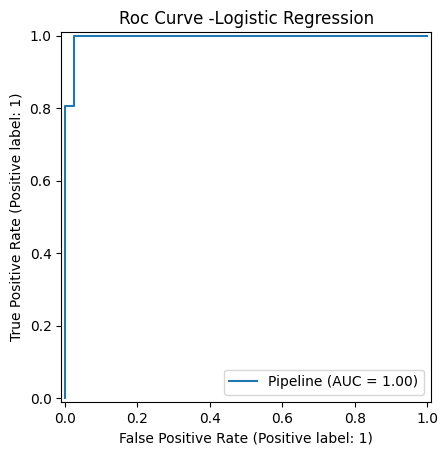

In [20]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_validate,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
    )


data =load_breast_cancer()
X =data.data
y =data.target
print("Feature shape : ",X.shape )
print("Target names : ", data.target_names)
print("Feature names : ",data.feature_names[:5])


x_train, x_test, y_train , y_test =train_test_split(X, y , test_size=0.2,random_state=42,stratify=y)
print(f"X_train shape : ",x_train.shape)
print(f"y_train shape : ",y_train.shape)
model = Pipeline([
    ("scaler",StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000))
])

#Cross validation 
cv =StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

scoring ={
    "accuracy":"accuracy",
    "precision":"precision",
    "recall":"recall",
    "f1":"f1",
    "roc_auc":"roc_auc"
}
print(type(scoring))
cv_results =cross_validate(
    model, 
    X=x_train, 
    y=y_train, 
    cv=cv,
    scoring=scoring,
    error_score='raise'
)


print("\nCross validation results ")
for metric in scoring.keys():
    scores =cv_results[f'test_{metric}']
    print(f'{metric}: {scores.mean():.4f} +- {scores.std():.4f}')


model.fit(x_train, y_train)
y_pred =model.predict(x_test)
y_prob =model.predict_proba(x_test)[:,1]

print("\nTest performance : ")
print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precisi0on : ", precision_score(y_test,y_pred))
print("Recall : ", recall_score(y_test, y_pred))
print("F1 score : ", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))
print("\nClassification report: ")



print(classification_report(y_test,y_pred, target_names=data.target_names))
cm =confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm , 
    display_labels= data.target_names
)

disp.plot()
plt.title("Confusion matrix - Logistic Regression ")
plt.show()

RocCurveDisplay.from_estimator(model,x_test,y_test)
plt.title("Roc Curve -Logistic Regression")
plt.show()